# 4-Class Defect Detection — Real Image Inference Test

Test **3 unseen images** against all four trained models:

| Model | Weights file |
|-------|-------------|
| MobileNetV2 (All-layers FT) | `mobilenetv2_4class_alllayers_final.h5` |
| MobileNetV3Small (FT) | `best_mobilenetv3_small_finetuned.weights.h5` |
| MobileNetV3Large (FT) | `best_mobilenetv3_large_finetuned.weights.h5` |
| Custom CA-CNN | `best_custom_ca_cnn_phase1.weights.h5` |

**Test images:** `stringing.jpeg` · `cracking.jpg` · `warping.png`

---
## 1. Imports & Configuration

In [2]:
print(5)

5


In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE = os.getcwd()   # should be /home/feriel/PFE/Defect-Detection

MODEL_FILES = {
    "MobileNetV2":      os.path.join(BASE, "mobilenetv2_4class_alllayers_final.h5"),
    "MobileNetV3Small": os.path.join(BASE, "best_mobilenetv3_small_finetuned.weights.h5"),
    "MobileNetV3Large": os.path.join(BASE, "best_mobilenetv3_large_finetuned.weights.h5"),
    "CA-CNN":           os.path.join(BASE, "best_custom_ca_cnn_phase1.weights.h5"),
}

TEST_IMAGES = {
    "stringing": os.path.join(BASE, "stringing.jpg"),
    "cracking":  os.path.join(BASE, "cracking2.jpg"),
    "warping":   os.path.join(BASE, "warping2.jpg"),
}

CLASS_NAMES = ["Cracking", "Stringing", "Warping", "No_Defect"]
IMG_SIZE    = (224, 224)

print(f"TensorFlow : {tf.__version__}")
print(f"Working dir: {BASE}")
for k, p in TEST_IMAGES.items():
    print(f"  {k:<12} → {'✅ found' if os.path.exists(p) else '❌ MISSING'} ({p})")

TensorFlow : 2.18.0
Working dir: /home/feriel/PFE/Defect-Detection
  stringing    → ✅ found (/home/feriel/PFE/Defect-Detection/stringing.jpg)
  cracking     → ✅ found (/home/feriel/PFE/Defect-Detection/cracking2.jpg)
  warping      → ✅ found (/home/feriel/PFE/Defect-Detection/warping2.jpg)


---
## 2. Load & Preview Test Images

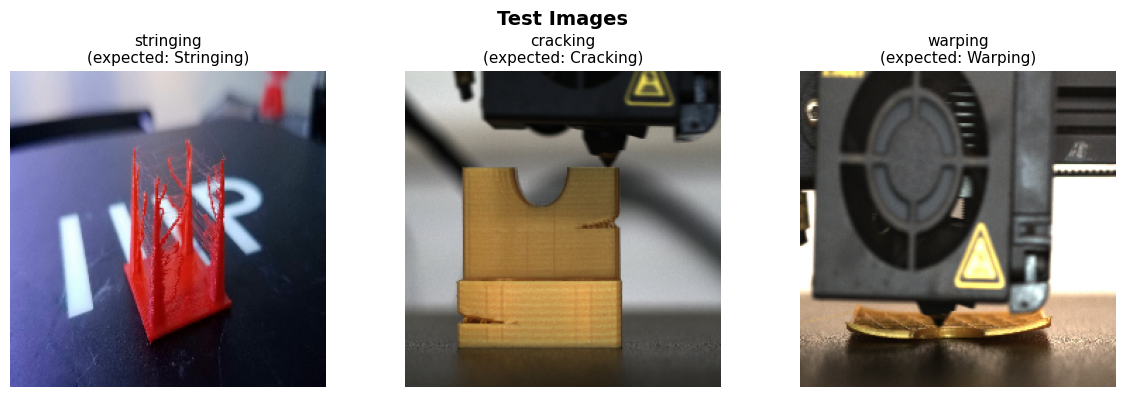

Images loaded — shape: (224, 224, 3)


In [48]:
def load_image(path):
    """Read any image format → float32 tensor (1, 224, 224, 3) in [0, 1]."""
    raw  = tf.io.read_file(path)
    # Decode PNG or JPEG transparently
    img  = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img  = tf.image.resize(img, IMG_SIZE)
    img  = tf.cast(img, tf.float32) / 255.0
    return img.numpy()   # (224, 224, 3)


# Load all test images
images_raw = {name: load_image(path) for name, path in TEST_IMAGES.items()}

# ── Show the 3 images side-by-side ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Test Images", fontsize=14, fontweight="bold")

EXPECTED = {"stringing": "Stringing", "cracking": "Cracking", "warping": "Warping"}

for ax, (name, img) in zip(axes, images_raw.items()):
    ax.imshow(img)
    ax.set_title(f"{name}\n(expected: {EXPECTED[name]})", fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()
print("Images loaded — shape:", next(iter(images_raw.values())).shape)

---
## 3. Rebuild Model Architectures & Load Weights

In [5]:
# ── MobileNetV2 (full .h5) ───────────────────────────────────────────────────
model_v2 = keras.models.load_model(MODEL_FILES["MobileNetV2"])
model_v2.trainable = False
print(f"MobileNetV2      loaded — {model_v2.count_params():,} params")


# ── MobileNetV3Small ──────────────────────────────────────────────────────────
def build_mobilenetv3_small():
    base = tf.keras.applications.MobileNetV3Small(
        input_shape=(224, 224, 3), include_top=False,
        weights=None, include_preprocessing=False)
    inp = layers.Input(shape=(224, 224, 3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation="relu")(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(4, activation="softmax")(x)
    return keras.Model(inp, out, name="MobileNetV3Small_Model")

model_v3s = build_mobilenetv3_small()
model_v3s.load_weights(MODEL_FILES["MobileNetV3Small"])
model_v3s.trainable = False
print(f"MobileNetV3Small loaded — {model_v3s.count_params():,} params")


# ── MobileNetV3Large ──────────────────────────────────────────────────────────
def build_mobilenetv3_large():
    base = tf.keras.applications.MobileNetV3Large(
        input_shape=(224, 224, 3), include_top=False,
        weights=None, include_preprocessing=False)
    inp = layers.Input(shape=(224, 224, 3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation="relu")(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(4, activation="softmax")(x)
    return keras.Model(inp, out, name="MobileNetV3Large_Model")

model_v3l = build_mobilenetv3_large()
model_v3l.load_weights(MODEL_FILES["MobileNetV3Large"])
model_v3l.trainable = False
print(f"MobileNetV3Large loaded — {model_v3l.count_params():,} params")


# ── CA-CNN ────────────────────────────────────────────────────────────────────
class CoordinateAttention(layers.Layer):
    def __init__(self, reduction=32, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        C = input_shape[-1]
        mid_ch = max(8, C // self.reduction)
        self.shared_conv = layers.Conv2D(mid_ch, 1, padding="same", use_bias=False)
        self.bn           = layers.BatchNormalization()
        self.relu         = layers.ReLU(max_value=6.0)
        self.conv_h       = layers.Conv2D(C, 1, padding="same")
        self.conv_w       = layers.Conv2D(C, 1, padding="same")
        super().build(input_shape)

    def call(self, x, training=False):
        H       = tf.shape(x)[1]
        pool_h  = tf.reduce_mean(x, axis=2, keepdims=True)
        pool_w  = tf.transpose(tf.reduce_mean(x, axis=1, keepdims=True), [0,2,1,3])
        y       = self.relu(self.bn(self.shared_conv(tf.concat([pool_h, pool_w], 1)), training=training))
        a_h     = tf.sigmoid(self.conv_h(y[:, :H, :, :]))
        a_w     = tf.transpose(tf.sigmoid(self.conv_w(y[:, H:, :, :])), [0,2,1,3])
        return x * a_h * a_w

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"reduction": self.reduction})
        return cfg


def inv_res_block(x, out_ch, stride=1, expand=6, name_prefix="irb"):
    in_ch    = x.shape[-1]
    shortcut = x
    if expand != 1:
        x = layers.Conv2D(in_ch*expand, 1, padding="same", use_bias=False,
                          name=f"{name_prefix}_expand_conv")(x)
        x = layers.BatchNormalization(name=f"{name_prefix}_expand_bn")(x)
        x = layers.ReLU(max_value=6.0, name=f"{name_prefix}_expand_relu")(x)
    x = layers.DepthwiseConv2D(3, strides=stride, padding="same", use_bias=False,
                               name=f"{name_prefix}_dw_conv")(x)
    x = layers.BatchNormalization(name=f"{name_prefix}_dw_bn")(x)
    x = layers.ReLU(max_value=6.0, name=f"{name_prefix}_dw_relu")(x)
    x = CoordinateAttention(reduction=32, name=f"{name_prefix}_ca")(x)
    x = layers.Conv2D(out_ch, 1, padding="same", use_bias=False,
                      name=f"{name_prefix}_proj_conv")(x)
    x = layers.BatchNormalization(name=f"{name_prefix}_proj_bn")(x)
    if stride == 1 and in_ch == out_ch:
        x = layers.Add(name=f"{name_prefix}_add")([shortcut, x])
    return x


def build_custom_ca_cnn():
    inp = layers.Input(shape=(224, 224, 3), name="input")
    x   = layers.Conv2D(32, 3, strides=2, padding="same", use_bias=False, name="stem_conv")(inp)
    x   = layers.BatchNormalization(name="stem_bn")(x)
    x   = layers.ReLU(max_value=6.0, name="stem_relu")(x)
    x   = inv_res_block(x, 16,  stride=1, expand=1, name_prefix="irb1")
    x   = inv_res_block(x, 24,  stride=2, expand=6, name_prefix="irb2")
    x   = inv_res_block(x, 32,  stride=2, expand=6, name_prefix="irb3")
    x   = inv_res_block(x, 64,  stride=2, expand=6, name_prefix="irb4")
    x   = inv_res_block(x, 96,  stride=1, expand=6, name_prefix="irb5")
    x   = layers.Conv2D(128, 1, padding="same", use_bias=False, name="trans_conv")(x)
    x   = layers.BatchNormalization(name="trans_bn")(x)
    x   = layers.ReLU(max_value=6.0, name="trans_relu")(x)
    x   = layers.GlobalAveragePooling2D(name="gap")(x)
    x   = layers.Dense(256, activation="relu", name="fc1")(x)
    x   = layers.Dropout(0.3, name="drop")(x)
    out = layers.Dense(4, activation="softmax", name="predictions")(x)
    return keras.Model(inp, out, name="Custom_CA_CNN")

model_ca = build_custom_ca_cnn()
model_ca.load_weights(MODEL_FILES["CA-CNN"])
model_ca.trainable = False
print(f"CA-CNN           loaded — {model_ca.count_params():,} params")


ALL_MODELS = {
    "MobileNetV2":      model_v2,
    "MobileNetV3Small": model_v3s,
    "MobileNetV3Large": model_v3l,
    "CA-CNN":           model_ca,
}
print("\n✅ All models ready.")

MobileNetV2      loaded — 2,586,948 params
MobileNetV3Small loaded — 1,087,860 params
MobileNetV3Large loaded — 3,243,396 params
CA-CNN           loaded — 182,180 params

✅ All models ready.


---
## 4. Run Predictions — All Models × All Images

In [49]:
def predict(model, img_np):
    """Return (predicted_class_name, confidence_percent, full_probs_array)."""
    inp    = img_np[np.newaxis, ...].astype(np.float32)   # (1,224,224,3)
    probs  = model(inp, training=False).numpy()[0]         # (4,)
    idx    = int(np.argmax(probs))
    return CLASS_NAMES[idx], float(probs[idx]) * 100, probs


# results[image_name][model_name] = (pred_class, confidence, probs)
results = {}
for img_name, img in images_raw.items():
    results[img_name] = {}
    for model_name, model in ALL_MODELS.items():
        pred, conf, probs = predict(model, img)
        results[img_name][model_name] = (pred, conf, probs)
        correct = "✅" if pred == EXPECTED[img_name] else "❌"
        print(f"  {img_name:<12} | {model_name:<20} → {pred:<12} {conf:.1f}%  {correct}")

print("\n✅ Predictions done.")

  stringing    | MobileNetV2          → Stringing    98.8%  ✅
  stringing    | MobileNetV3Small     → Stringing    86.7%  ✅
  stringing    | MobileNetV3Large     → Cracking     72.5%  ❌
  stringing    | CA-CNN               → Stringing    100.0%  ✅
  cracking     | MobileNetV2          → Stringing    97.2%  ❌
  cracking     | MobileNetV3Small     → Cracking     94.9%  ✅
  cracking     | MobileNetV3Large     → Cracking     98.1%  ✅
  cracking     | CA-CNN               → Cracking     98.8%  ✅
  warping      | MobileNetV2          → Stringing    91.4%  ❌
  warping      | MobileNetV3Small     → Stringing    93.8%  ❌
  warping      | MobileNetV3Large     → Cracking     72.9%  ❌
  warping      | CA-CNN               → Stringing    97.5%  ❌

✅ Predictions done.


---
## 5. Visual Results — Image Grid with Confidence Bars

Each row = one test image. Each column = one model.  
Green border = correct prediction · Red border = wrong prediction.

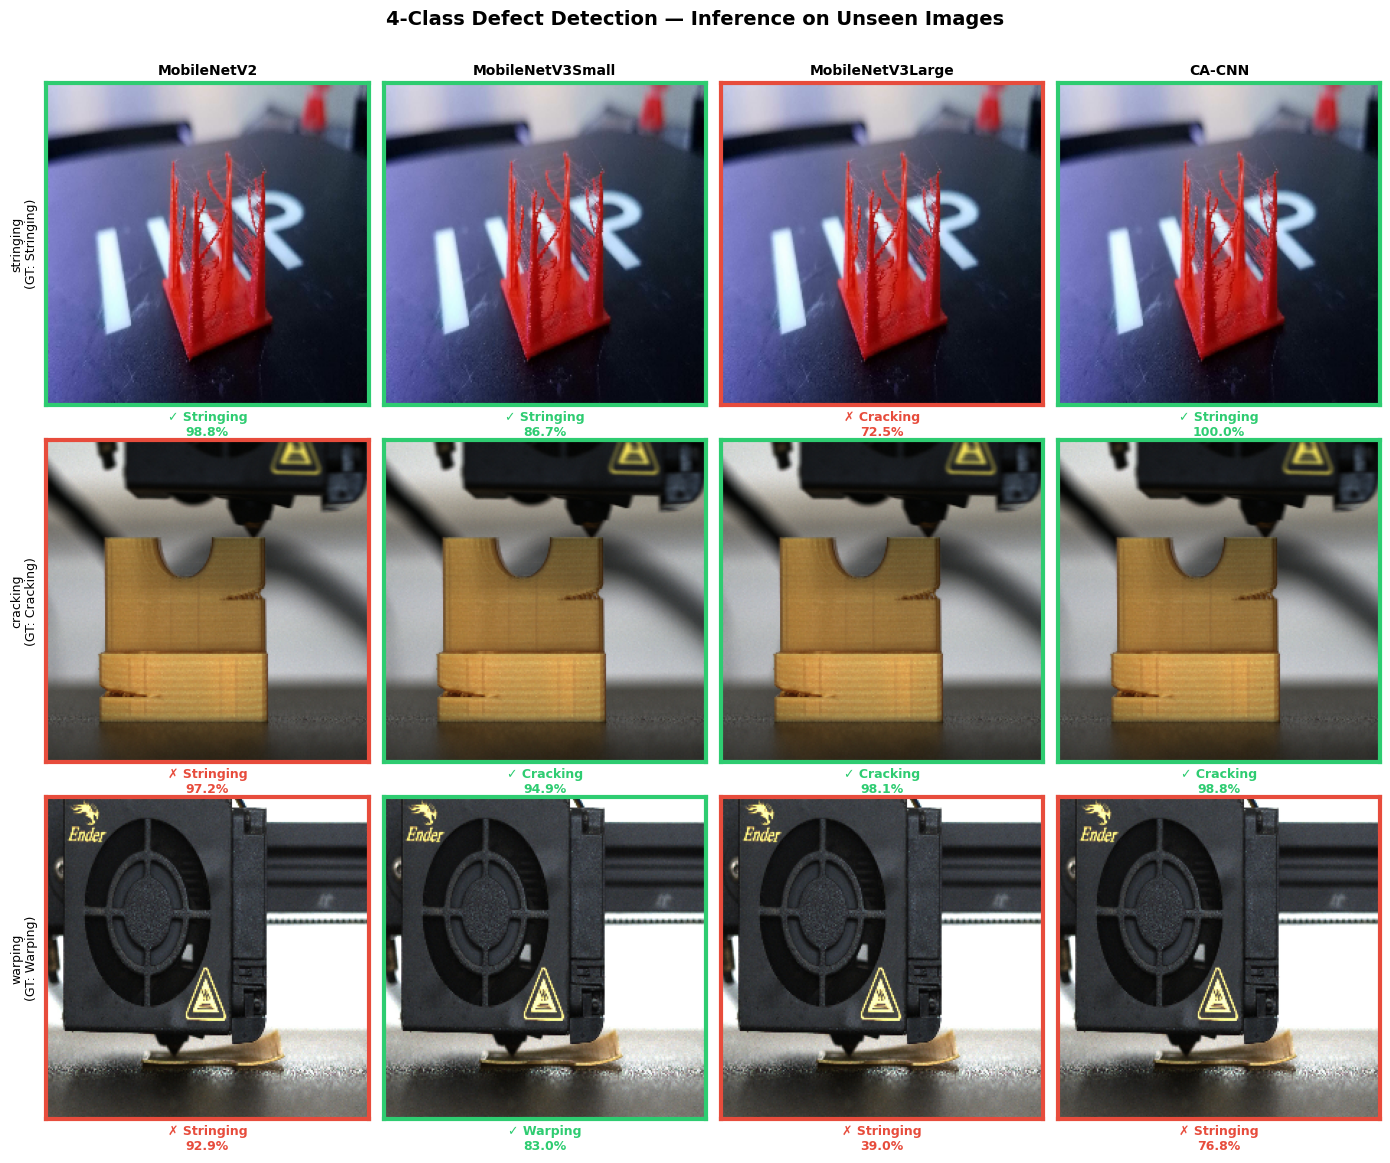

Grid saved → test_new_images_grid.png


In [47]:
MODEL_NAMES = list(ALL_MODELS.keys())
IMG_NAMES   = list(images_raw.keys())
N_IMGS      = len(IMG_NAMES)
N_MODELS    = len(MODEL_NAMES)

fig, axes = plt.subplots(
    N_IMGS, N_MODELS,
    figsize=(N_MODELS * 3.5, N_IMGS * 3.8),
)
fig.suptitle(
    "4-Class Defect Detection — Inference on Unseen Images",
    fontsize=14, fontweight="bold", y=1.01
)

BAR_COLORS  = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
BORDER_OK   = "#2ecc71"   # green — correct
BORDER_FAIL = "#e74c3c"   # red   — wrong

for row, img_name in enumerate(IMG_NAMES):
    for col, model_name in enumerate(MODEL_NAMES):
        ax = axes[row][col]
        pred, conf, probs = results[img_name][model_name]
        correct           = pred == EXPECTED[img_name]

        # ── Show image with coloured border ───────────────────────────────────
        ax.imshow(images_raw[img_name])
        border_color = BORDER_OK if correct else BORDER_FAIL
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)

        # ── Title: model name (top row only) ──────────────────────────────────
        if row == 0:
            ax.set_title(model_name, fontsize=10, fontweight="bold", pad=6)

        # ── Y-axis label: image name (left column only) ────────────────────────
        if col == 0:
            ax.set_ylabel(
                f"{img_name}\n(GT: {EXPECTED[img_name]})",
                fontsize=9, labelpad=6
            )

        ax.set_xticks([])
        ax.set_yticks([])

        # ── Prediction label at the bottom of the image ───────────────────────
        tick = "✓" if correct else "✗"
        ax.set_xlabel(
            f"{tick} {pred}\n{conf:.1f}%",
            fontsize=9,
            color=border_color,
            fontweight="bold",
        )

plt.tight_layout()
plt.savefig(os.path.join(BASE, "test_new_images_grid.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Grid saved → test_new_images_grid.png")

---
## 6. Per-Class Confidence Scores — Bar Charts

One figure per test image. Each subplot shows the softmax probability
distribution for all 4 classes, for each model.

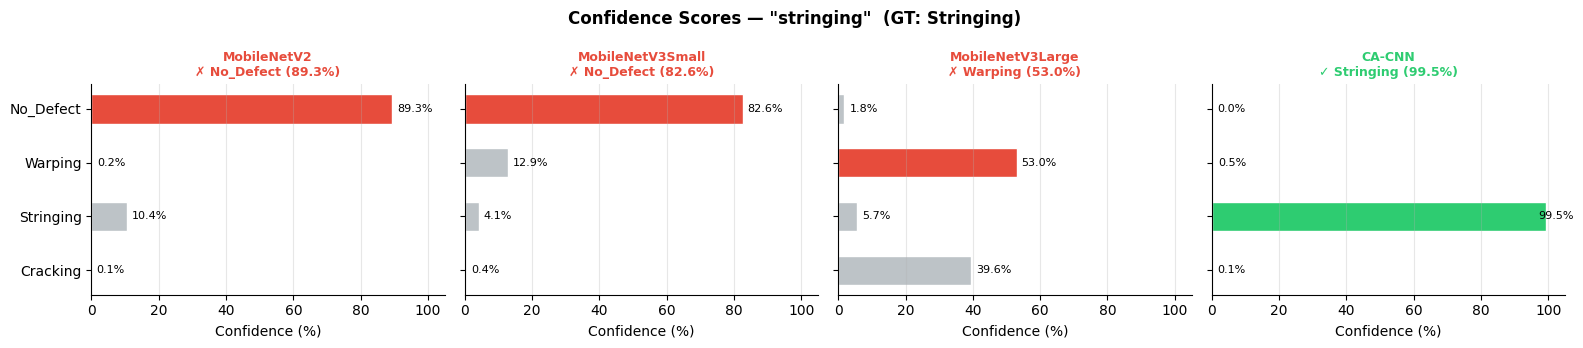

Saved → test_confidence_stringing.png


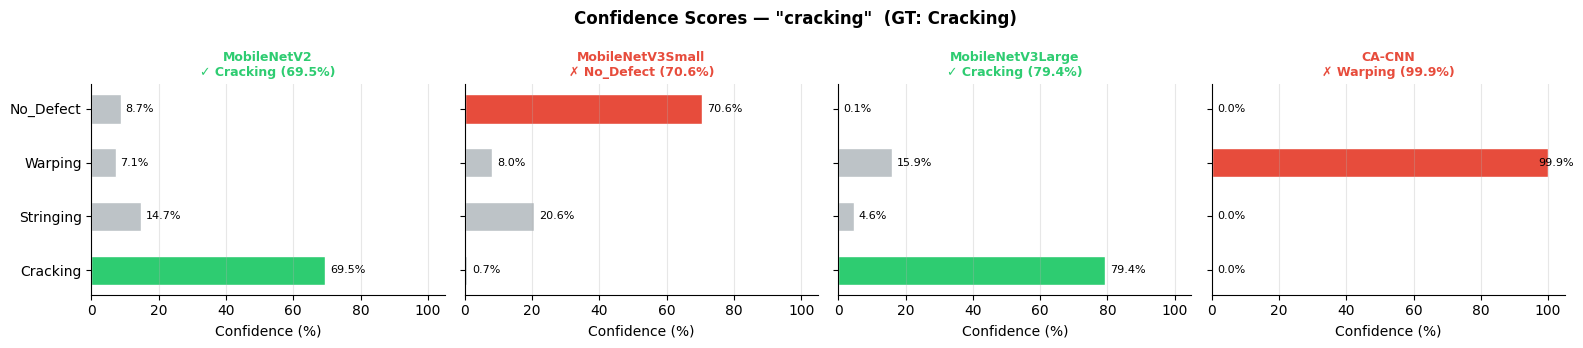

Saved → test_confidence_cracking.png


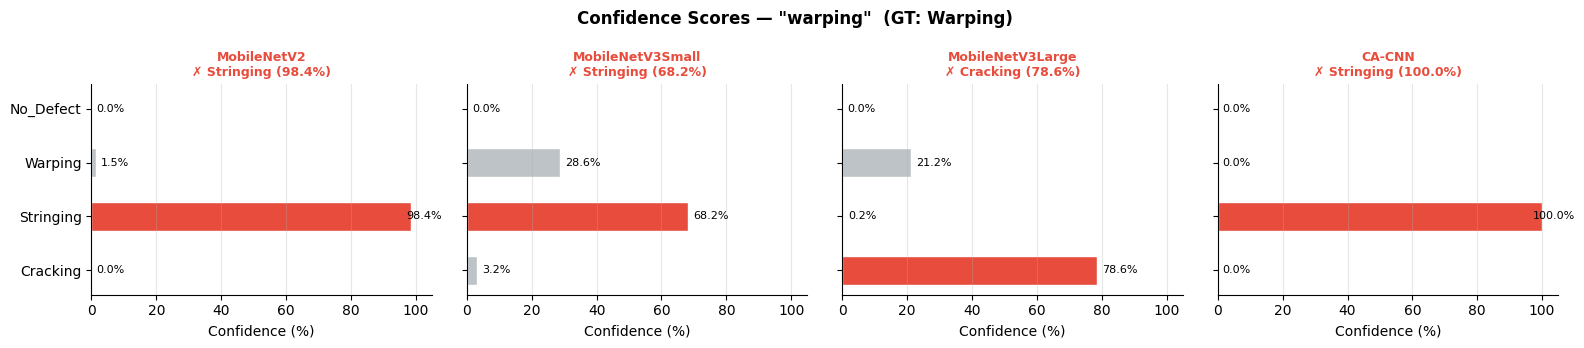

Saved → test_confidence_warping.png


In [8]:
for img_name in IMG_NAMES:
    fig, axes = plt.subplots(1, N_MODELS, figsize=(N_MODELS * 4, 3.5), sharey=True)
    fig.suptitle(
        f'Confidence Scores — "{img_name}"  (GT: {EXPECTED[img_name]})',
        fontsize=12, fontweight="bold"
    )

    for ax, model_name in zip(axes, MODEL_NAMES):
        pred, conf, probs = results[img_name][model_name]
        colors = [
            ("#2ecc71" if c == pred and pred == EXPECTED[img_name]
             else "#e74c3c" if c == pred
             else "#bdc3c7")
            for c in CLASS_NAMES
        ]
        bars = ax.barh(CLASS_NAMES, probs * 100, color=colors, edgecolor="white", height=0.55)

        # Value labels
        for bar, v in zip(bars, probs * 100):
            ax.text(min(v + 1.5, 97), bar.get_y() + bar.get_height() / 2,
                    f"{v:.1f}%", va="center", fontsize=8)

        correct = pred == EXPECTED[img_name]
        tick    = "✓" if correct else "✗"
        ax.set_title(f"{model_name}\n{tick} {pred} ({conf:.1f}%)",
                     fontsize=9, fontweight="bold",
                     color="#2ecc71" if correct else "#e74c3c")
        ax.set_xlim(0, 105)
        ax.set_xlabel("Confidence (%)")
        ax.grid(axis="x", alpha=0.3)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(BASE, f"test_confidence_{img_name}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → test_confidence_{img_name}.png")

---
## 7. Summary Table

In [9]:
rows = []
for img_name in IMG_NAMES:
    for model_name in MODEL_NAMES:
        pred, conf, probs = results[img_name][model_name]
        rows.append({
            "Image":       img_name,
            "Ground Truth": EXPECTED[img_name],
            "Model":       model_name,
            "Predicted":   pred,
            "Confidence (%)":  round(conf, 1),
            "Correct":     "✅" if pred == EXPECTED[img_name] else "❌",
        })

df = pd.DataFrame(rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
print(df.to_string(index=False))

# ── Score per model ───────────────────────────────────────────────────────────
print("\n" + "="*50)
print("Score per model (out of 3 images):")
print("="*50)
for model_name in MODEL_NAMES:
    sub     = df[df["Model"] == model_name]
    correct = (sub["Correct"] == "✅").sum()
    print(f"  {model_name:<20} {correct}/3  "
          + "⭐" * correct)

    Image Ground Truth            Model Predicted  Confidence (%) Correct
stringing    Stringing      MobileNetV2 No_Defect            89.3       ❌
stringing    Stringing MobileNetV3Small No_Defect            82.6       ❌
stringing    Stringing MobileNetV3Large   Warping            53.0       ❌
stringing    Stringing           CA-CNN Stringing            99.5       ✅
 cracking     Cracking      MobileNetV2  Cracking            69.5       ✅
 cracking     Cracking MobileNetV3Small No_Defect            70.6       ❌
 cracking     Cracking MobileNetV3Large  Cracking            79.4       ✅
 cracking     Cracking           CA-CNN   Warping            99.9       ❌
  warping      Warping      MobileNetV2 Stringing            98.4       ❌
  warping      Warping MobileNetV3Small Stringing            68.2       ❌
  warping      Warping MobileNetV3Large  Cracking            78.6       ❌
  warping      Warping           CA-CNN Stringing           100.0       ❌

Score per model (out of 3 images):
  